# 02 | Pembagian Data (Train / Validation / Test) + EDA Ringkas

**Input:** `data/processed/daily_merged.csv` (hasil notebook 01)  
**Output:** `data/splits/train.csv`, `val.csv`, `test.csv`, dan `daily_with_split.csv`

### Prinsip pembagian:
1. **Data dibagi secara kronologis tanpa shuffle.** Train untuk periode paling awal dan Test untuk periode paling akhir.
2. **Embargo 1 hari perdagangan** di antara split. Target `ret_next` pada baris hari `t` memakai kurs hari `t+1` tanpa embargo, target baris terakhir train akan bersinggungan dengan baris pertama validation.
3. **EDA hanya pada data train**, kecuali gambar distribusi kelas per split yang bersifat deskriptif.
4. Semua statistik yang perlu belajar dari data (mis. TF-IDF, scaler) yang ada pada notebook 03 **hanya fit pada train**.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 100

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError(
        "Repo root tidak ditemukan. Jalankan notebook dari dalam repo "
        "nlp-trio-bertiga (folder manapun di dalamnya)."
    )

ROOT = _find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

# Reuse split_dataset.py milik track baseline kurs-only,
from src.jisdor.split_dataset import chronological_split, TRAIN_RATIO, VAL_RATIO, EMBARGO

C:\Users\Mikail Achmad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.3)
  from scipy.sparse import csr_matrix, issparse


## 1. Konfigurasi & muat data

In [2]:
# Rasio & embargo mengikuti src/jisdor/split_dataset.py
print(f"Rasio (dari split_dataset.py): train={TRAIN_RATIO}, val={VAL_RATIO}, embargo={EMBARGO}")

# None = otomatis: jika berita hanya mencakup sebagian kecil rentang JISDOR 
# Set False jika dataset berita sudah lengkap 5 tahun.
RESTRICT_TO_NEWS_SPAN = None

daily = pd.read_csv(DATA / "processed" / "daily_merged.csv", parse_dates=["date"])
daily[["text_title", "text_body"]] = daily[["text_title", "text_body"]].fillna("")
daily = daily.sort_values("date").reset_index(drop=True)
print("Baris:", len(daily), "|", daily["date"].min().date(), "->", daily["date"].max().date())

Rasio (dari split_dataset.py): train=0.8, val=0.1, embargo=1
Baris: 1200 | 2021-09-02 -> 2026-08-31


In [3]:
# cek cakupan berita terhadap rentang JISDOR
news_days = daily.loc[daily["has_news"] == 1, "date"]
span_ratio = (news_days.max() - news_days.min()).days / max((daily["date"].max() - daily["date"].min()).days, 1)
print(f"Berita mencakup {span_ratio:.0%} dari rentang JISDOR "
      f"({news_days.min().date()} -> {news_days.max().date()})")

restrict = (span_ratio < 0.5) if RESTRICT_TO_NEWS_SPAN is None else RESTRICT_TO_NEWS_SPAN
if restrict:
    daily = daily[(daily["date"] >= news_days.min()) & (daily["date"] <= news_days.max())].reset_index(drop=True)
    print(f"[info] Dibatasi ke rentang berita -> {len(daily)} hari perdagangan")

# baris tanpa target tidak bisa dipakai
before = len(daily)
daily = daily.dropna(subset=["log_ret", "ret_next"]).reset_index(drop=True)
print(f"Baris tanpa target dibuang: {before - len(daily)} | sisa: {len(daily)}")

Berita mencakup 16% dari rentang JISDOR (2021-09-02 -> 2022-06-16)
[info] Dibatasi ke rentang berita -> 192 hari perdagangan
Baris tanpa target dibuang: 0 | sisa: 192


## 2. Pembagian kronologis

In [4]:
train, val, test = chronological_split(daily, date_col="date")

# uji: urutan waktu tidak boleh tumpang tindih
assert train["date"].max() < val["date"].min() < val["date"].max() < test["date"].min()

summary = pd.DataFrame({
    "baris": [len(train), len(val), len(test)],
    "mulai": [s["date"].min().date() for s in (train, val, test)],
    "selesai": [s["date"].max().date() for s in (train, val, test)],
    "hari_ada_berita": [int(s["has_news"].sum()) for s in (train, val, test)],
    "total_artikel": [int(s["n_articles"].sum()) for s in (train, val, test)],
    "%_USD_naik (direction)": [round(s["direction"].mean() * 100, 1) for s in (train, val, test)],
}, index=["train", "val", "test"])
summary

,baris,mulai,selesai,hari_ada_berita,total_artikel,%_USD_naik (direction)
train,152,2021-09-02,2022-04-07,64,100,51.3
val,18,2022-04-11,2022-05-13,10,15,61.1
test,20,2022-05-18,2022-06-16,7,13,60.0


In [5]:
# Simpan
out = DATA / "splits"
out.mkdir(parents=True, exist_ok=True)
train.to_csv(out / "train.csv", index=False)
val.to_csv(out / "val.csv", index=False)
test.to_csv(out / "test.csv", index=False)

# tabel gabungan dengan kolom split
pd.concat([train.assign(split="train"), val.assign(split="val"), test.assign(split="test")]) \
  .to_csv(out / "daily_with_split.csv", index=False)
print("Tersimpan di", out)

if (summary["hari_ada_berita"] == 0).any():
    print("[peringatan] Ada split tanpa berita sama sekali. Perluas dataset berita atau ubah proporsi split.")

Tersimpan di d:\Kuliah\Tugas dan Projek\Pemrosesan Bahasa Alami\repo\nlp-trio-bertiga\data\splits


## 3. EDA data train

Yang dilihat:   
(a) bentuk kurs & posisi tiap split,  
(b) distribusi return dan keseimbangan kelas,  
(c) sebaran berita,  
(d) apakah volatilitas berbeda saat ada berita / setelah libur.

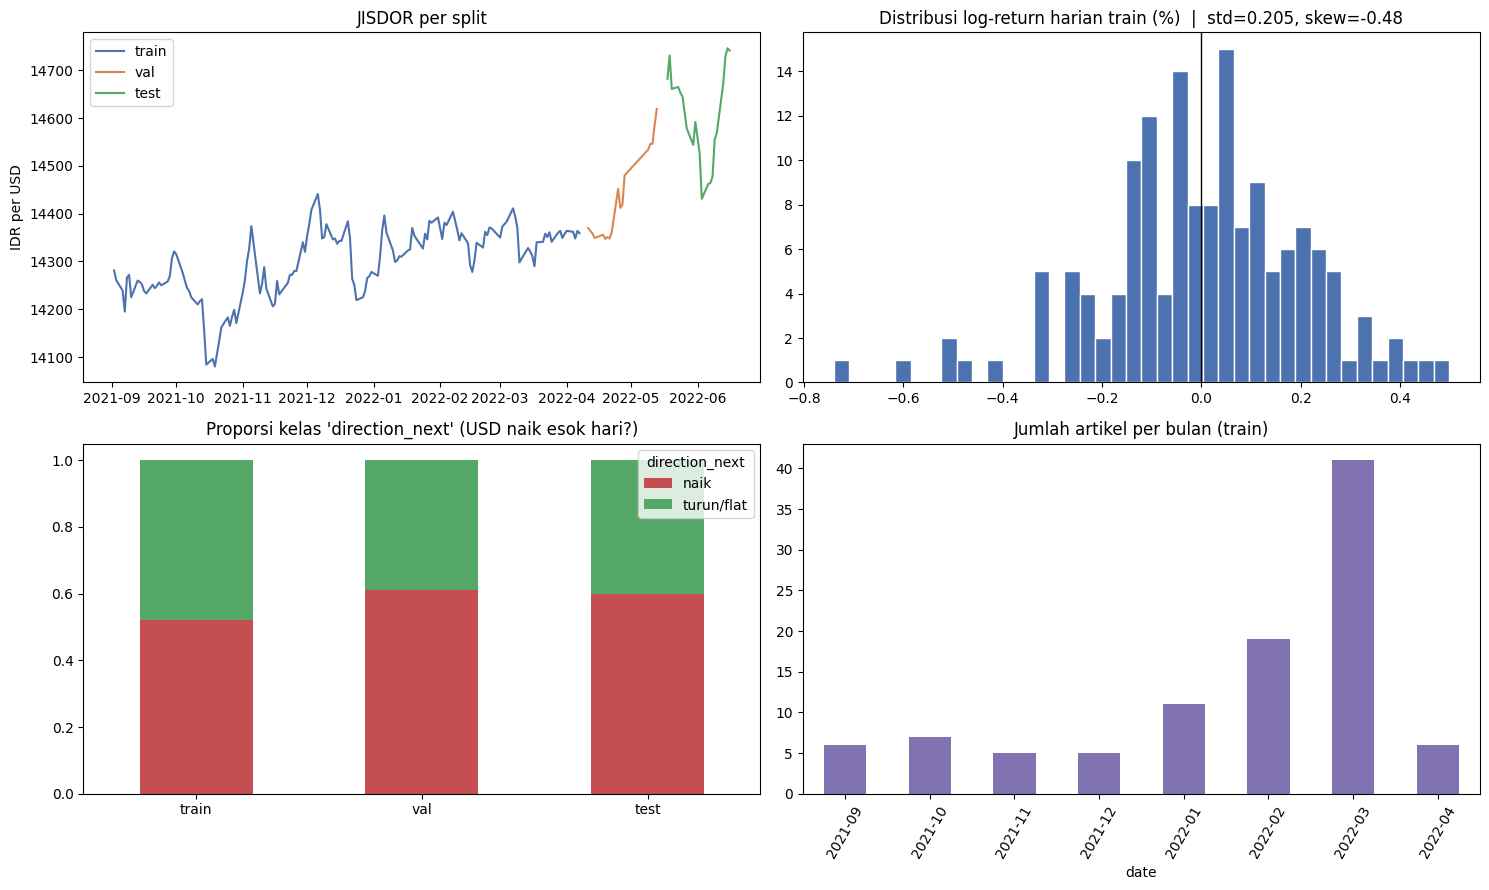

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# (a) kurs + pembagian split
ax[0, 0].plot(train["date"], train["rate"], label="train", color="#4C72B0")
ax[0, 0].plot(val["date"], val["rate"], label="val", color="#DD8452")
ax[0, 0].plot(test["date"], test["rate"], label="test", color="#55A868")
ax[0, 0].set_title("JISDOR per split"); ax[0, 0].legend(); ax[0, 0].set_ylabel("IDR per USD")

# (b) distribusi log-return (train)
r = train["log_ret"] * 100
ax[0, 1].hist(r, bins=40, color="#4C72B0", edgecolor="white")
ax[0, 1].axvline(0, color="k", lw=1)
ax[0, 1].set_title(f"Distribusi log-return harian train (%)  |  std={r.std():.3f}, skew={r.skew():.2f}")

# (c) keseimbangan kelas per split
bal = pd.DataFrame({"train": train["direction_next"].value_counts(normalize=True),
                    "val": val["direction_next"].value_counts(normalize=True),
                    "test": test["direction_next"].value_counts(normalize=True)}).rename(index={0.0: "turun/flat", 1.0: "naik"})
bal.T.plot.bar(ax=ax[1, 0], stacked=True, color=["#C44E52", "#55A868"])
ax[1, 0].set_title("Proporsi kelas 'direction_next' (USD naik esok hari?)"); ax[1, 0].tick_params(axis="x", rotation=0)

# (d) jumlah artikel per bulan (train)
monthly = train.groupby(train["date"].dt.strftime("%Y-%m"))["n_articles"].sum()
monthly.plot.bar(ax=ax[1, 1], color="#8172B2")
ax[1, 1].tick_params(axis="x", rotation=60)
ax[1, 1].set_title("Jumlah artikel per bulan (train)")
plt.tight_layout(); plt.show()

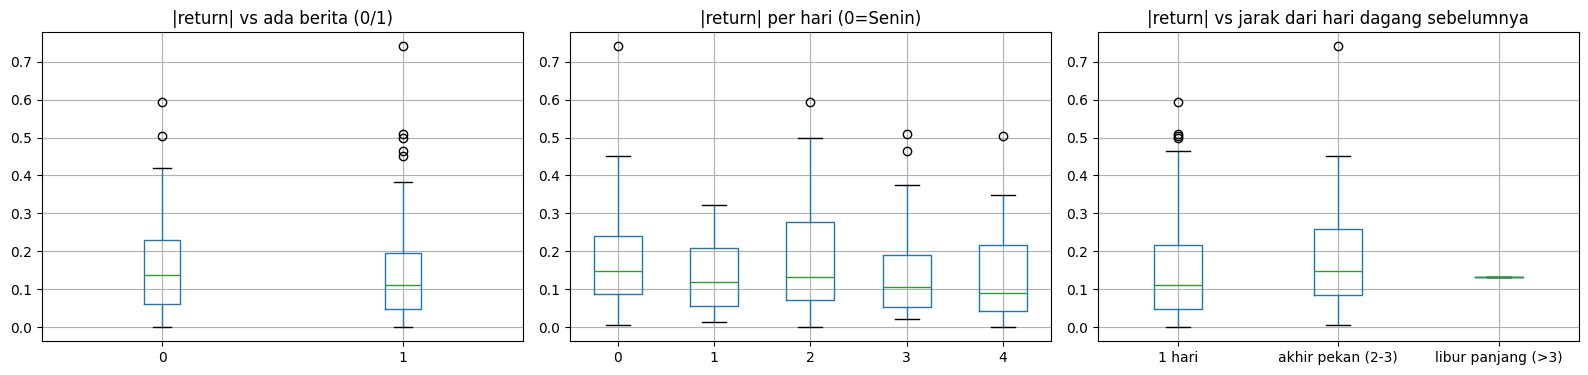

          count    mean  median
has_news                       
0            88  0.1604  0.1368
1            64  0.1518  0.1114


In [7]:
# Volatilitas vs kondisi berita per kalender
t = train.copy()
t["abs_ret_pct"] = t["log_ret"].abs() * 100
t["kategori_gap"] = pd.cut(t["gap_days"], bins=[0, 1, 3, 100], labels=["1 hari", "akhir pekan (2-3)", "libur panjang (>3)"])

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
t.boxplot(column="abs_ret_pct", by="has_news", ax=ax[0]); ax[0].set_title("|return| vs ada berita (0/1)")
t.boxplot(column="abs_ret_pct", by="dayofweek", ax=ax[1]); ax[1].set_title("|return| per hari (0=Senin)")
t.boxplot(column="abs_ret_pct", by="kategori_gap", ax=ax[2]); ax[2].set_title("|return| vs jarak dari hari dagang sebelumnya")
for a in ax: a.set_xlabel("")
plt.suptitle(""); plt.tight_layout(); plt.show()

print(t.groupby("has_news")["abs_ret_pct"].agg(["count", "mean", "median"]).round(4))

In [8]:
# Statistik teks pada hari yang punya berita
tn = train[train["has_news"] == 1]
stats = pd.DataFrame({
    "n_articles": tn["n_articles"],
    "kata_judul": tn["text_title"].str.split().str.len(),
    "kata_isi": tn["text_body"].str.split().str.len(),
})
print("Hari berita di train:", len(tn), f"({len(tn)/len(train):.1%} dari hari train)")
stats.describe().round(1)

Hari berita di train: 64 (42.1% dari hari train)


,n_articles,kata_judul,kata_isi
count,64.0,64.0,64.0
mean,1.6,20.8,1406.6
std,1.0,13.9,1133.3
min,1.0,7.0,262.0
25%,1.0,11.0,719.5
50%,1.0,14.0,1048.0
75%,2.0,26.2,1496.8
max,4.0,59.0,5116.0


### Catatan 
- Jika persentase hari-dengan-berita rendah, fitur NLP akan bernilai 0 di sebagian besar baris. Setelah scraping penuh, proporsi ini seharusnya naik drastis.
- Pembanding dasarnya adalah naive baseline.
- Notebook 03 memakai `daily_with_split.csv` agar tiap artikel otomatis masuk split yang sama dengan hari perdagangannya.